<a href="https://colab.research.google.com/github/nicoCT04/Deep_Q_Learning/blob/main/notebook/proyecto2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto 2 — Deep Q-Learning en Space Invaders

**CC3092 · Deep Learning y Sistemas Inteligentes** — Universidad del Valle de Guatemala
**Nicolás Concuá**

Guatemala, octubre de 2026

Repositorio: <https://github.com/nicoCT04/Deep_Q_Learning>

---

Este notebook documenta el desarrollo completo de un agente de Aprendizaje por
Refuerzo que juega **Space Invaders** (`ALE/SpaceInvaders-v5`). Está organizado
siguiendo la estructura del trabajo escrito:

1. **Análisis del entorno** (definición del problema, observación, acción, recompensa).
2. **Metodología** (algoritmo, arquitectura, exploración, hiperparámetros).
3. **Iteraciones de entrenamiento** (historial de experimentos, curvas).
4. **Evaluación y video** del agente final (política greedy, competencia).
5. **Discusión y conclusiones**.

> El **entrenamiento** se ejecuta en Google Colab con GPU (sección 2). Este
> notebook, corrido localmente, cubre el análisis del entorno (sección 1) y la
> evaluación/grabación del agente final (sección 4). Las secciones de Colab
> incluyen guardado de *checkpoints* en Google Drive como respaldo.

## 0. Configuración e importaciones

Se fijan semillas para reproducibilidad y se resuelven rutas de forma robusta
(el notebook funciona tanto si se corre desde la raíz del repositorio como desde
`notebook/`).

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# --- Reproducibilidad ---
SEED = 42
np.random.seed(SEED)

# --- Rutas robustas: raíz del repo y carpeta de figuras ---
_cwd = os.getcwd()
REPO_ROOT = os.path.dirname(_cwd) if os.path.basename(_cwd) == "notebook" else _cwd
REPORTS_DIR = os.path.join(REPO_ROOT, "reports")
VIDEOS_DIR = os.path.join(REPO_ROOT, "videos")
MODELS_DIR = os.path.join(REPO_ROOT, "models")
NOTEBOOK_DIR = os.path.join(REPO_ROOT, "notebook")
for d in (REPORTS_DIR, VIDEOS_DIR, MODELS_DIR):
    os.makedirs(d, exist_ok=True)

# Permite importar ale_utils.py tanto desde la raíz como desde notebook/
if NOTEBOOK_DIR not in sys.path:
    sys.path.insert(0, NOTEBOOK_DIR)

import gymnasium as gym
import ale_py
gym.register_envs(ale_py)

ENV_ID = "ALE/SpaceInvaders-v5"
print("REPO_ROOT:", REPO_ROOT)
print("gymnasium:", gym.__version__, "| ale_py:", ale_py.__version__)

REPO_ROOT: /Users/nicolasconcua/Documents/UVG/8ctavosemestre/deepLearning/Deep_Q_Learning
gymnasium: 1.3.0 | ale_py: 0.12.1


## 1. Definición del problema y análisis del entorno

Antes de entrenar cualquier agente se analiza el entorno, de forma análoga al EDA
de un problema supervisado.

### 1.1 Descripción de `ALE/SpaceInvaders-v5`

Space Invaders es un juego de Atari 2600 en el que el jugador controla un cañón
que se mueve horizontalmente en la parte inferior de la pantalla y dispara a
oleadas de invasores que descienden progresivamente. El agente interactúa con el
juego a través del **Arcade Learning Environment (ALE)** expuesto como un entorno
de Gymnasium [1, 2].

- **Objetivo**: destruir a todos los invasores acumulando el mayor puntaje
  posible, evitando ser alcanzado por sus disparos y evitando que lleguen al
  fondo de la pantalla.
- **Recompensa**: puntos que otorga el juego al destruir invasores. Los aliens de
  filas superiores valen más, por lo que la recompensa por paso toma valores
  discretos (múltiplos de 5). Es una señal **dispersa**: la mayoría de los pasos
  dan recompensa cero.
- **Vidas**: el agente inicia con **3 vidas**; pierde una cada vez que un disparo
  enemigo lo alcanza. `info["lives"]` reporta las vidas restantes.
- **Fin de episodio**: `terminated = True` cuando se agotan las vidas;
  `truncated = True` cuando se alcanza el tope de `max_num_frames_per_episode`
  (108000 frames ALE ≈ 30 min de juego real).

### 1.2 Configuración por defecto de la versión `-v5`

La variante `-v5` implementa el protocolo de evaluación recomendado por Machado
et al. [3]:

- **`frameskip = 4`**: cada acción del agente se repite durante 4 frames del
  emulador (el entorno ya devuelve el máximo por par de frames para evitar
  parpadeo de sprites).
- **`repeat_action_probability = 0.25`** (*sticky actions*): con probabilidad
  0.25 el emulador repite la acción anterior en lugar de la nueva. Introduce
  estocasticidad para evitar que el agente memorice una secuencia fija de
  acciones.
- **`full_action_space = False`**: se usa el subconjunto **mínimo** de 6 acciones
  específico de Space Invaders (ver 1.4).

Las siguientes celdas confirman empíricamente estos valores.

In [2]:
# --- Inspección del entorno crudo (sin wrappers) ---
env = gym.make(ENV_ID, render_mode="rgb_array")

print("Espacio de observación:", env.observation_space)
print("Espacio de acción     :", env.action_space)
print("Significado de acciones:", env.unwrapped.get_action_meanings())
print("Parámetros de la spec  :", env.spec.kwargs)

obs, info = env.reset(seed=SEED)
print("\nObservación tras reset -> shape:", obs.shape, "dtype:", obs.dtype,
      "rango:", (int(obs.min()), int(obs.max())))
print("info tras reset:", {k: info[k] for k in ('lives', 'frame_number') if k in info})
env.close()

Espacio de observación: Box(0, 255, (210, 160, 3), uint8)
Espacio de acción     : Discrete(6)
Significado de acciones: ['NOOP', 'FIRE', 'RIGHT', 'LEFT', 'RIGHTFIRE', 'LEFTFIRE']
Parámetros de la spec  : {'game': 'space_invaders', 'repeat_action_probability': 0.25, 'full_action_space': False, 'frameskip': 4, 'max_num_frames_per_episode': 108000, 'render_mode': 'rgb_array'}

Observación tras reset -> shape: (210, 160, 3) dtype: uint8 rango: (0, 181)
info tras reset: {'lives': 3, 'frame_number': 0}


A.L.E: Arcade Learning Environment (version 0.12.1+8a8fafb)
[Powered by Stella]


### 1.3 Espacio de observación y preprocesamiento

La observación cruda es una imagen **RGB de 210×160×3** en `uint8`. Alimentar la
red con esta imagen a color y a plena resolución es costoso e innecesario: el
color aporta poca información en Space Invaders y la resolución completa infla el
número de parámetros. Se aplica el preprocesamiento estándar de la literatura de
DQN [1]:

1. **Escala de grises** (de 3 canales a 1).
2. **Redimensionado a 84×84**.
3. **Apilado de 4 frames** consecutivos (*frame stacking*), para que la
   observación contenga información temporal (velocidad y dirección de disparos e
   invasores), ya que un solo frame no basta para inferir movimiento.
4. **Normalización** de los píxeles a [0, 1] dentro de la red.

La figura siguiente compara un frame RGB crudo con su versión preprocesada
(gris, 84×84).

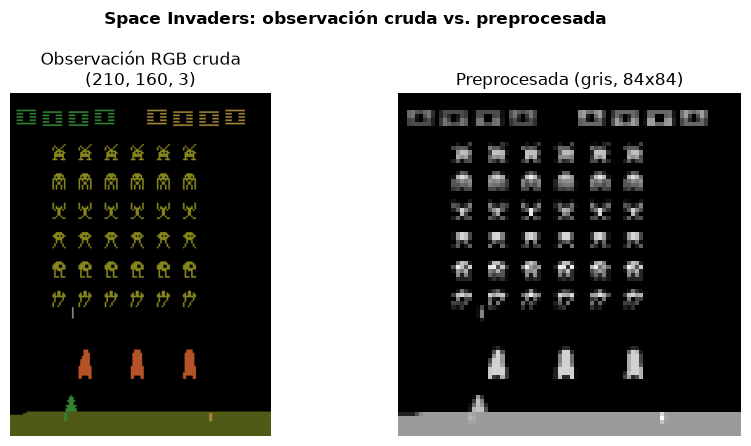

In [3]:
import cv2

def preprocesar_frame(frame_rgb, tam=84):
    '''Escala de grises + redimensionado a tam x tam, como en DQN [1].'''
    gris = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2GRAY)
    peq = cv2.resize(gris, (tam, tam), interpolation=cv2.INTER_AREA)
    return peq

# Tomar un frame representativo (unos pasos dentro de la partida)
env = gym.make(ENV_ID, render_mode="rgb_array")
env.reset(seed=SEED)
for _ in range(60):
    frame, _, term, trunc, _ = env.step(env.action_space.sample())
    if term or trunc:
        env.reset(seed=SEED)
env.close()

frame_prep = preprocesar_frame(frame)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(frame)
axes[0].set_title(f"Observación RGB cruda\n{frame.shape}")
axes[0].axis("off")
axes[1].imshow(frame_prep, cmap="gray")
axes[1].set_title(f"Preprocesada (gris, {frame_prep.shape[0]}x{frame_prep.shape[1]})")
axes[1].axis("off")
fig.suptitle("Space Invaders: observación cruda vs. preprocesada", fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(REPORTS_DIR, "observacion_rgb_vs_preprocesada.png"),
            dpi=130, bbox_inches="tight")
plt.show()

### 1.4 Espacio de acción

El espacio de acción es `Discrete(6)`; el subconjunto mínimo de Space Invaders:

| Acción | Nombre | Efecto |
|:------:|:-------|:-------|
| 0 | `NOOP` | No hacer nada |
| 1 | `FIRE` | Disparar |
| 2 | `RIGHT` | Moverse a la derecha |
| 3 | `LEFT` | Moverse a la izquierda |
| 4 | `RIGHTFIRE` | Moverse a la derecha y disparar |
| 5 | `LEFTFIRE` | Moverse a la izquierda y disparar |

Se usa este subconjunto de 6 acciones (`full_action_space = False`) en lugar de
las 18 acciones genéricas de Atari: reduce el espacio de salida de la red y acota
la exploración a acciones con sentido en el juego, acelerando el aprendizaje sin
perder capacidad expresiva.

### 1.5 Análisis de la señal de recompensa

Se ejecuta un episodio con acciones aleatorias para caracterizar la recompensa:
su magnitud, su frecuencia (densa vs. dispersa) y la acumulación a lo largo del
tiempo. Esto motiva las decisiones de preprocesamiento de la recompensa.

In [4]:
env = gym.make(ENV_ID, render_mode="rgb_array")
obs, info = env.reset(seed=SEED)
recompensas, retorno_acumulado = [], []
acc = 0.0
term = trunc = False
while not (term or trunc):
    obs, r, term, trunc, info = env.step(env.action_space.sample())
    recompensas.append(float(r))
    acc += float(r)
    retorno_acumulado.append(acc)
env.close()

recompensas = np.array(recompensas)
no_cero = recompensas[recompensas != 0]
print("Pasos del episodio (aleatorio):", len(recompensas))
print("Retorno total:", recompensas.sum())
print("Valores de recompensa distintos:", sorted(set(recompensas.tolist())))
print(f"Fracción de pasos con recompensa != 0: {(recompensas != 0).mean():.3%}")
print("Recompensa media por paso:", round(recompensas.mean(), 4))

Pasos del episodio (aleatorio): 514
Retorno total: 210.0
Valores de recompensa distintos: [0.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0]
Fracción de pasos con recompensa != 0: 2.335%
Recompensa media por paso: 0.4086


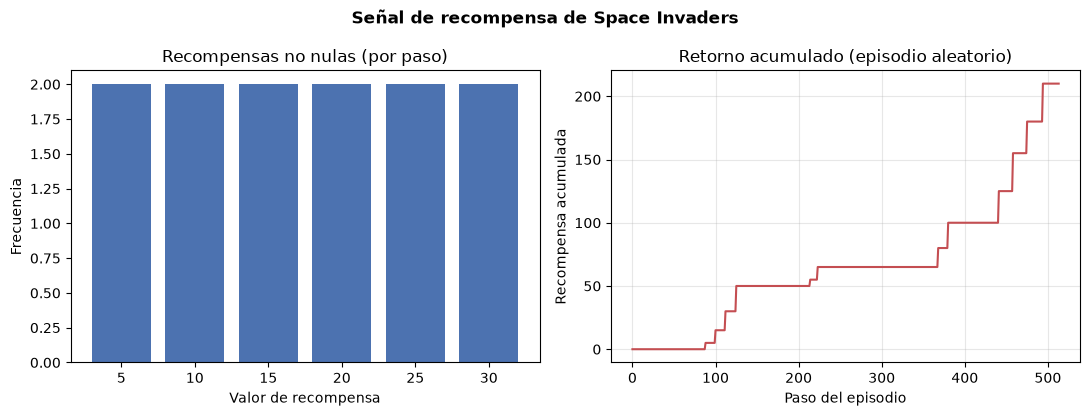

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# (a) Distribución de las recompensas no nulas
vals, cuentas = np.unique(no_cero, return_counts=True)
axes[0].bar([str(int(v)) for v in vals], cuentas, color="#4C72B0")
axes[0].set_title("Recompensas no nulas (por paso)")
axes[0].set_xlabel("Valor de recompensa")
axes[0].set_ylabel("Frecuencia")

# (b) Retorno acumulado a lo largo del episodio
axes[1].plot(retorno_acumulado, color="#C44E52")
axes[1].set_title("Retorno acumulado (episodio aleatorio)")
axes[1].set_xlabel("Paso del episodio")
axes[1].set_ylabel("Recompensa acumulada")
axes[1].grid(alpha=0.3)

fig.suptitle("Señal de recompensa de Space Invaders", fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(REPORTS_DIR, "analisis_recompensa.png"),
            dpi=130, bbox_inches="tight")
plt.show()

**Observaciones sobre la recompensa:**

- Es **dispersa**: solo una pequeña fracción de los pasos recibe recompensa
  distinta de cero (el resto son ceros mientras el agente se mueve o falla).
- Toma **valores discretos de distinta magnitud** (múltiplos de 5, según la fila
  del invasor destruido). Esta heterogeneidad puede desestabilizar el
  entrenamiento de los valores Q.
- **Decisión de diseño — *reward clipping*:** se recorta la recompensa a su signo
  (`{-1, 0, +1}`), técnica estándar de DQN [1]. Homogeniza la escala entre juegos
  y estabiliza el gradiente. Como consecuencia, la señal que optimiza el agente
  es "¿acerté un disparo?" y no "¿cuántos puntos exactos gané?"; el puntaje real
  (sin recortar) se mide aparte en la evaluación, que es la métrica de la
  competencia.
- **No se aplica *reward shaping*** adicional: la recompensa nativa del juego ya
  está alineada con el objetivo (destruir invasores = sobrevivir y puntuar).

### 1.6 Decisiones de diseño derivadas del análisis

Resumen de las decisiones que se arrastran a la fase de entrenamiento:

| Aspecto | Decisión | Justificación |
|:--------|:---------|:--------------|
| Observación | Gris 84×84, stack de 4 frames | Reduce dimensionalidad; captura movimiento [1] |
| Acciones | Subconjunto mínimo (6) | Exploración más eficiente que las 18 genéricas |
| Recompensa | *Reward clipping* a {-1,0,+1} | Estabiliza el aprendizaje de Q [1] |
| Manejo de vidas | *Episodic life* en entrenamiento | Cada vida perdida termina el "episodio" de entrenamiento → señal de fin más frecuente; en evaluación se juega el episodio completo (3 vidas) |
| Estocasticidad | Se conservan *sticky actions* (0.25) y `frameskip=4` | Protocolo de evaluación estándar [3]; evita sobreajuste a secuencias fijas |
| Frame skip | 4 (por defecto de `-v5`) | Menos pasos de decisión por segundo de juego → entrenamiento más rápido |

Estos wrappers se implementan en la fase de entrenamiento mediante el
`AtariWrapper` de Stable-Baselines3 más el apilado de frames, garantizando que el
**mismo preprocesamiento** se use en entrenamiento y evaluación (requisito de la
competencia).

## 2. Metodología de desarrollo y entrenamiento

Esta sección describe el algoritmo, la arquitectura y los hiperparámetros usados,
y contiene el código de **entrenamiento pensado para Google Colab (GPU)**. El
entrenamiento de un agente de Atari requiere millones de pasos, inviable en CPU;
por eso se ejecuta en Colab y se guardan *checkpoints* en Google Drive como
respaldo (ver 2.5).

### 2.1 Algoritmo de RL

Se eligió **DQN (Deep Q-Network)** [1] con la implementación de
**Stable-Baselines3 (SB3)** [4]. Justificación:

- Space Invaders tiene **espacio de acción discreto** (6 acciones), el escenario
  natural de DQN (aprende una función de valor de acción Q(s,a) y actúa por
  argmax). Algoritmos como PPO/A2C también aplican, pero DQN es el estándar
  histórico para Atari desde imágenes y es coherente con el tema del proyecto
  ("Deep Q-Learning").
- SB3 es una librería madura y verificada, lo que reduce errores de
  implementación y permite concentrar el esfuerzo en el análisis y la
  experimentación (el enunciado permite explícitamente usar librería documentando
  las decisiones).
- DQN incorpora las dos ideas que estabilizan el aprendizaje con redes profundas:
  **replay buffer** (rompe la correlación temporal de las muestras) y **red
  objetivo** (*target network*, fija los objetivos durante varios pasos).

Como posible iteración adicional se contempla **Double DQN** [5] (reduce el sesgo
de sobreestimación de los valores Q); ver sección 3.

### 2.2 Arquitectura de la red

Se usa la CNN de la publicación original de DQN (`NatureCNN`, la `CnnPolicy` por
defecto de SB3), adecuada a la observación preprocesada de **4×84×84**:

| Capa | Configuración | Activación |
|:-----|:--------------|:-----------|
| Conv1 | 32 filtros, 8×8, stride 4 | ReLU |
| Conv2 | 64 filtros, 4×4, stride 2 | ReLU |
| Conv3 | 64 filtros, 3×3, stride 1 | ReLU |
| Flatten + Densa | 512 unidades | ReLU |
| Salida | 6 valores Q (uno por acción) | lineal |

La entrada son los 4 frames apilados (información temporal); la salida son los
valores Q de las 6 acciones, de donde la política greedy toma el argmax.

### 2.3 Exploración vs. explotación

Estrategia **ε-greedy** con ε decreciente: al inicio el agente actúa casi al azar
(exploración) y ε decae linealmente hasta un valor pequeño (explotación). En la
**evaluación** se usa ε=0 (política greedy pura), como exige la competencia.

### 2.4 Hiperparámetros de entrenamiento

Valores base tomados de la configuración afinada de SB3/RL Zoo para Atari, punto
de partida de las iteraciones de la sección 3:

| Hiperparámetro | Valor base | Rol |
|:---------------|:-----------|:----|
| Optimizador | Adam | — |
| Función de pérdida | Huber (smooth L1) | Robusta a valores Q atípicos |
| Tasa de aprendizaje | 1e-4 | — |
| Factor de descuento γ | 0.99 | Horizonte de recompensa futura |
| Tamaño del replay buffer | 100 000 | Memoria de experiencias |
| `learning_starts` | 100 000 | Pasos aleatorios antes de entrenar |
| Tamaño de batch | 32 | — |
| `train_freq` | 4 | Entrena cada 4 pasos |
| Actualización de la red objetivo | cada 1 000 pasos | Estabilidad de los objetivos |
| ε (exploración) | 1.0 → 0.01 | Decae en el 10% inicial del entrenamiento |
| Reward clipping | {-1, 0, +1} | Vía `AtariWrapper` |

> **Nota de memoria:** un buffer de 100 000 transiciones de 4×84×84 en `uint8`
> ocupa ~2.7 GB de RAM; encaja en Colab. Si hiciera falta más, se usa
> `optimize_memory_usage=True` o se reduce el buffer.

### 2.5 Configuración de Google Colab (paso a paso)

1. Abrir este notebook en Colab (o subirlo).
2. **Runtime → Change runtime type → Hardware accelerator: GPU (T4)** y guardar.
3. Ejecutar las celdas de esta sección en orden: instalan dependencias, montan
   Google Drive y lanzan el entrenamiento.
4. Los *checkpoints* se guardan en `MyDrive/Proyecto2_SpaceInvaders/` cada cierto
   número de pasos. **Si la sesión se corta** (límite de tiempo / inactividad),
   se reanuda desde el último checkpoint con la celda 2.10.
5. Al terminar, se descarga el modelo final (`.zip`) a la carpeta `models/` del
   repositorio para versionarlo y usarlo en la evaluación (sección 4).

> Colab gratuito desconecta sesiones tras ~12 h de uso o ~90 min de inactividad;
> por eso el guardado periódico es indispensable como respaldo.

In [6]:
# 2.6 Detección de entorno (Colab vs. local) y rutas de artefactos
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Bandera de seguridad: el entrenamiento largo NO corre en un run local/automático.
# Ponerla en True al entrenar en Colab.
ENTRENAR = IN_COLAB

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE_DIR = "/content/drive/MyDrive/Proyecto2_SpaceInvaders"
else:
    # Respaldo local (para prototipar sin Drive).
    DRIVE_DIR = os.path.join(REPO_ROOT, "artefactos_entrenamiento")

CKPT_DIR = os.path.join(DRIVE_DIR, "checkpoints")
BEST_DIR = os.path.join(DRIVE_DIR, "best_model")
LOG_DIR = os.path.join(DRIVE_DIR, "logs")
for d in (DRIVE_DIR, CKPT_DIR, BEST_DIR, LOG_DIR):
    os.makedirs(d, exist_ok=True)

print("IN_COLAB:", IN_COLAB, "| ENTRENAR:", ENTRENAR)
print("Artefactos en:", DRIVE_DIR)

IN_COLAB: False | ENTRENAR: False
Artefactos en: /Users/nicolasconcua/Documents/UVG/8ctavosemestre/deepLearning/Deep_Q_Learning/artefactos_entrenamiento


In [7]:
# 2.7 Instalación de dependencias (solo en Colab)
if IN_COLAB:
    import subprocess, sys
    subprocess.run([
        sys.executable, "-m", "pip", "install", "-q",
        "gymnasium[atari]", "ale-py", "stable-baselines3[extra]",
    ], check=True)
    print("Dependencias instaladas.")
else:
    print("Entorno local: se asume que las dependencias ya están instaladas.")

Entorno local: se asume que las dependencias ya están instaladas.


In [8]:
# 2.8 Construcción del entorno de Atari con el preprocesamiento estándar
# make_atari_env aplica el AtariWrapper (gris 84x84, frameskip, episodic life,
# reward clipping); VecFrameStack apila 4 frames. El MISMO preprocesamiento se
# reutiliza en la evaluación (sección 4) para que la observación coincida.
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.vec_env import VecFrameStack

N_ENVS = 1          # DQN usa un solo entorno
N_STACK = 4         # frames apilados

def crear_entorno_atari(env_id=ENV_ID, n_envs=N_ENVS, n_stack=N_STACK, seed=SEED):
    '''Entorno vectorizado de Atari con wrappers estándar + apilado de frames.'''
    env = make_atari_env(env_id, n_envs=n_envs, seed=seed)
    env = VecFrameStack(env, n_stack=n_stack)
    return env

if ENTRENAR:
    vec_env = crear_entorno_atari()
    print("Entorno de entrenamiento:", vec_env.observation_space, vec_env.action_space)

In [9]:
# 2.9 Definición del modelo DQN y callbacks de respaldo
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import CheckpointCallback, EvalCallback

# Hiperparámetros base (sección 2.4). Ajustables por iteración (sección 3).
HYPERPARAMS = dict(
    learning_rate=1e-4,
    buffer_size=100_000,
    learning_starts=100_000,
    batch_size=32,
    gamma=0.99,
    train_freq=4,
    gradient_steps=1,
    target_update_interval=1_000,
    exploration_fraction=0.1,
    exploration_final_eps=0.01,
    optimize_memory_usage=False,
)

# Cada cuántos pasos guardar checkpoint (respaldo ante desconexión de Colab).
SAVE_FREQ = 100_000
NOMBRE_MODELO = "dqn_spaceinvaders"

if ENTRENAR:
    modelo = DQN(
        "CnnPolicy",
        vec_env,
        verbose=1,
        seed=SEED,
        tensorboard_log=LOG_DIR,
        **HYPERPARAMS,
    )

    checkpoint_cb = CheckpointCallback(
        save_freq=SAVE_FREQ,
        save_path=CKPT_DIR,
        name_prefix=NOMBRE_MODELO,
        save_replay_buffer=False,  # el buffer es muy pesado; guardamos solo pesos
        save_vecnormalize=False,
    )

    eval_env = crear_entorno_atari(seed=SEED + 1000)
    eval_cb = EvalCallback(
        eval_env,
        best_model_save_path=BEST_DIR,
        log_path=LOG_DIR,
        eval_freq=50_000,
        n_eval_episodes=5,
        deterministic=True,
    )
    print("Modelo y callbacks listos.")

In [10]:
# 2.10 Entrenamiento (o reanudación desde checkpoint)
# TOTAL_TIMESTEPS por corrida; se puede aumentar por iteraciones (sección 3).
TOTAL_TIMESTEPS = 2_000_000

import glob

def ultimo_checkpoint(ckpt_dir=CKPT_DIR, prefijo=NOMBRE_MODELO):
    '''Ruta del checkpoint más reciente, o None si no hay.'''
    cks = glob.glob(os.path.join(ckpt_dir, f"{prefijo}_*_steps.zip"))
    if not cks:
        return None
    def pasos(p):
        try:
            return int(os.path.basename(p).split("_")[-2])
        except (IndexError, ValueError):
            return 0
    return max(cks, key=pasos)

if ENTRENAR:
    ck = ultimo_checkpoint()
    if ck is not None:
        print("Reanudando desde:", ck)
        modelo = DQN.load(ck, env=vec_env, tensorboard_log=LOG_DIR)
        reset_num = False
    else:
        print("Entrenando desde cero.")
        reset_num = True

    modelo.learn(
        total_timesteps=TOTAL_TIMESTEPS,
        callback=[checkpoint_cb, eval_cb],
        reset_num_timesteps=reset_num,
        progress_bar=True,
    )

    ruta_final_drive = os.path.join(DRIVE_DIR, f"{NOMBRE_MODELO}.zip")
    modelo.save(ruta_final_drive)
    print("Modelo final guardado en:", ruta_final_drive)
else:
    print("ENTRENAR=False: se omite el entrenamiento (ejecutar en Colab con GPU).")

ENTRENAR=False: se omite el entrenamiento (ejecutar en Colab con GPU).


### 2.11 Descargar el modelo final al repositorio

Tras entrenar en Colab, descargar `dqn_spaceinvaders.zip` desde
`MyDrive/Proyecto2_SpaceInvaders/` y colocarlo en `models/` del repositorio. Así
la sección 4 (evaluación y video) puede cargarlo y el modelo queda versionado.

```python
# En Colab, para descargar directamente:
# from google.colab import files
# files.download(os.path.join(DRIVE_DIR, "dqn_spaceinvaders.zip"))
```

## 3. Resultados de iteraciones

Se documentan **tres iteraciones** del agente. La primera se entrenó en Google
Colab (T4); las dos siguientes, más largas (8M pasos), se entrenaron **localmente
en un MacBook Pro M4 Pro usando MPS**, corriéndolas **en paralelo** (se midió
~1.74x de throughput total al lanzar dos procesos, porque en DQN de un solo
entorno la GPU queda subutilizada esperando a la CPU).

### 3.1 Tabla de experimentos

| Iteración | Configuración | Pasos | Entorno | Puntaje greedy (prom / máx) |
|:----------|:--------------|:------|:--------|:----------------------------|
| It.1 | DQN base (LR 1e-4) | 2 M | Colab (T4) | 625 / 1255 |
| **It.2 (final)** | DQN base (LR 1e-4) | 8 M | Local (M4 Pro, MPS) | **1022 / 1815** |
| It.3 | DQN (LR 2.5e-4) | 8 M | Local (M4 Pro, MPS) | 648 / 1175 |

*(Evaluación de competencia: 20 episodios greedy, episodio completo de 3 vidas,
sin reward clipping.)*

**Hallazgos clave:**
- **Más pasos = mucho mejor:** pasar de 2 M a 8 M casi **duplicó el promedio**
  (625 -> 1022) y subió el máximo de 1255 a **1815**.
- **La tasa de aprendizaje más alta (It.3, 2.5e-4) resultó peor**, no mejor: el
  LR base (1e-4) con más pasos fue la mejor combinación. Correr It.2 e It.3 en
  paralelo permitió compararlas y quedarse con la ganadora.

Las figuras siguientes muestran la recompensa de la iteración inicial (2 M,
Colab), la progresión del puntaje real del modelo final (8 M) y la comparación
directa It.2 vs It.3.

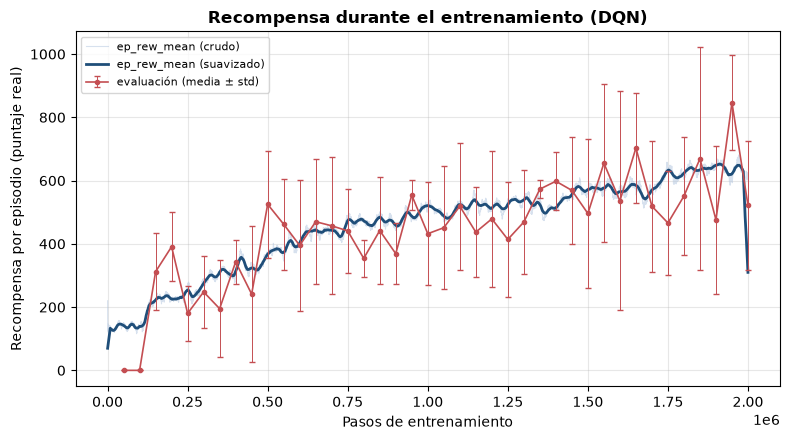

In [11]:
# 3.3 Curva de recompensa (entrenamiento + evaluacion)
import csv as _csv

def _leer_csv(nombre):
    ruta = os.path.join(REPORTS_DIR, nombre)
    if not os.path.exists(ruta):
        return None
    with open(ruta) as f:
        r = _csv.DictReader(f)
        cols = {k: [] for k in r.fieldnames}
        for fila in r:
            for k, v in fila.items():
                cols[k].append(float(v))
    return {k: np.array(v) for k, v in cols.items()}

def _suavizar(v, k=101):
    if len(v) < k:
        return v
    return np.convolve(v, np.ones(k) / k, mode="same")

rew = _leer_csv("curva_train_reward.csv")
ev = _leer_csv("curva_eval.csv")
if rew is not None and ev is not None:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(rew["pasos"], rew["ep_rew_mean"], color="#B0C4DE", alpha=0.5, lw=0.8,
            label="ep_rew_mean (crudo)")
    ax.plot(rew["pasos"], _suavizar(rew["ep_rew_mean"]), color="#1f4e79", lw=2,
            label="ep_rew_mean (suavizado)")
    ax.errorbar(ev["pasos"], ev["eval_mean"], yerr=ev["eval_std"], fmt="o-",
                color="#C44E52", ms=3, lw=1.2, elinewidth=0.7, capsize=2,
                label="evaluación (media ± std)")
    ax.set_xlabel("Pasos de entrenamiento")
    ax.set_ylabel("Recompensa por episodio (puntaje real)")
    ax.set_title("Recompensa durante el entrenamiento (DQN)", fontweight="bold")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(os.path.join(REPORTS_DIR, "curva_recompensa.png"), dpi=130, bbox_inches="tight")
    plt.show()
else:
    print("CSV de curvas no encontrado (ver reports/). Figura pre-generada: reports/curva_recompensa.png")

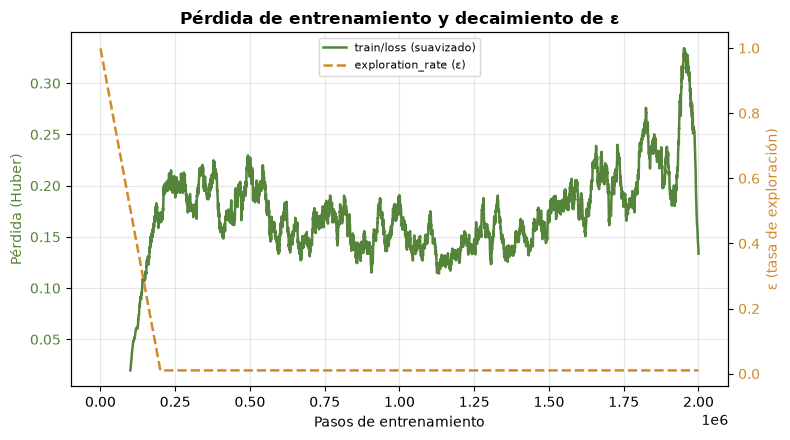

In [12]:
# 3.4 Curva de perdida y decaimiento de epsilon
loss = _leer_csv("curva_train_loss.csv")
expl = _leer_csv("curva_train_expl.csv")
if loss is not None and expl is not None:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(loss["pasos"], _suavizar(loss["loss"]), color="#55843b", lw=1.8,
            label="train/loss (suavizado)")
    ax.set_xlabel("Pasos de entrenamiento")
    ax.set_ylabel("Pérdida (Huber)", color="#55843b")
    ax.tick_params(axis="y", labelcolor="#55843b"); ax.grid(alpha=0.3)
    ax2 = ax.twinx()
    ax2.plot(expl["pasos"], expl["exploration_rate"], color="#d1892a", lw=1.8, ls="--",
             label="exploration_rate (ε)")
    ax2.set_ylabel("ε (tasa de exploración)", color="#d1892a")
    ax2.tick_params(axis="y", labelcolor="#d1892a")
    lineas = ax.get_lines() + ax2.get_lines()
    ax.legend(lineas, [l.get_label() for l in lineas], fontsize=8, loc="upper center")
    ax.set_title("Pérdida de entrenamiento y decaimiento de ε", fontweight="bold")
    fig.tight_layout()
    fig.savefig(os.path.join(REPORTS_DIR, "curva_perdida.png"), dpi=130, bbox_inches="tight")
    plt.show()
else:
    print("Figura pre-generada: reports/curva_perdida.png")

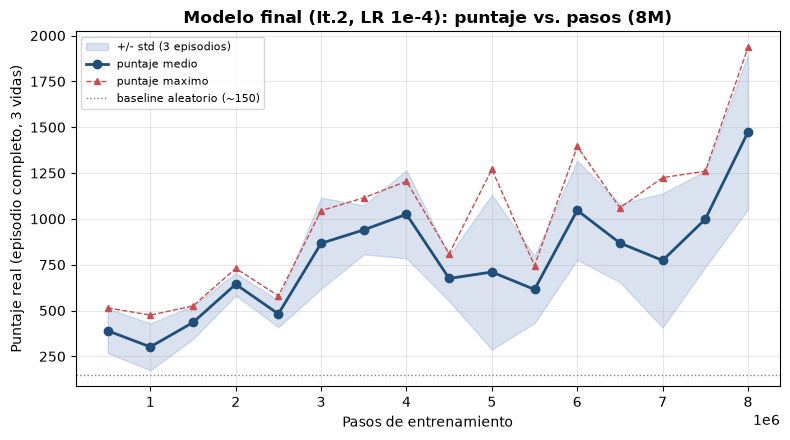

In [13]:
# 3.5 Puntaje real del modelo final (It.2, 8M) vs. pasos de entrenamiento
ck = _leer_csv("curva_checkpoints_8M.csv")
if ck is not None:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.fill_between(ck["pasos"], ck["score_mean"] - ck["score_std"],
                    ck["score_mean"] + ck["score_std"], color="#4C72B0", alpha=0.2,
                    label="+/- std (3 episodios)")
    ax.plot(ck["pasos"], ck["score_mean"], "o-", color="#1f4e79", lw=2, label="puntaje medio")
    ax.plot(ck["pasos"], ck["score_max"], "^--", color="#C44E52", lw=1, ms=5, label="puntaje maximo")
    ax.axhline(150, color="gray", ls=":", lw=1, label="baseline aleatorio (~150)")
    ax.set_xlabel("Pasos de entrenamiento")
    ax.set_ylabel("Puntaje real (episodio completo, 3 vidas)")
    ax.set_title("Modelo final (It.2, LR 1e-4): puntaje vs. pasos (8M)", fontweight="bold")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(os.path.join(REPORTS_DIR, "curva_puntaje_8M.png"), dpi=130, bbox_inches="tight")
    plt.show()
else:
    print("Figura pre-generada: reports/curva_puntaje_8M.png")

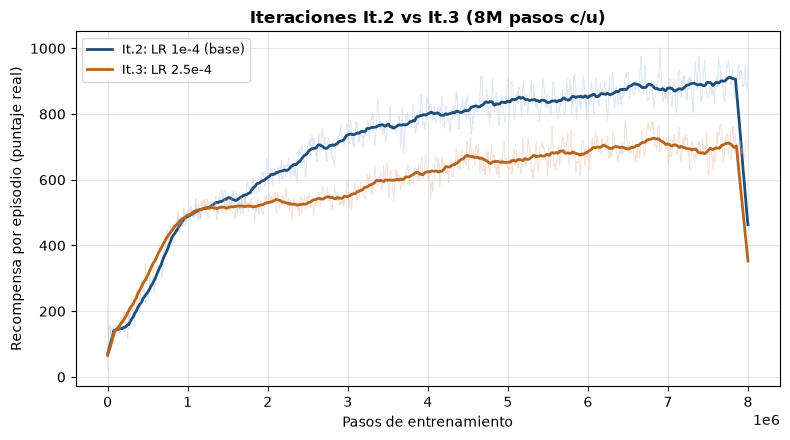

In [14]:
# 3.5b Comparacion de iteraciones It.2 (LR 1e-4) vs It.3 (LR 2.5e-4)
A = _leer_csv("curva_A_reward.csv")
B = _leer_csv("curva_B_reward.csv")
if A is not None and B is not None:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(A["pasos"], A["ep_rew_mean"], color="#B0C4DE", alpha=0.4, lw=0.7)
    ax.plot(A["pasos"], _suavizar(A["ep_rew_mean"], 51), color="#1f4e79", lw=2, label="It.2: LR 1e-4 (base)")
    ax.plot(B["pasos"], B["ep_rew_mean"], color="#E3B7A0", alpha=0.4, lw=0.7)
    ax.plot(B["pasos"], _suavizar(B["ep_rew_mean"], 51), color="#B5651D", lw=2, label="It.3: LR 2.5e-4")
    ax.set_xlabel("Pasos de entrenamiento")
    ax.set_ylabel("Recompensa por episodio (puntaje real)")
    ax.set_title("Iteraciones It.2 vs It.3 (8M pasos c/u)", fontweight="bold")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(os.path.join(REPORTS_DIR, "curva_A_vs_B.png"), dpi=130, bbox_inches="tight")
    plt.show()
else:
    print("Figura pre-generada: reports/curva_A_vs_B.png")

### 3.6 Problemas encontrados y cómo se abordaron

- **Corte de energía / desconexión de Colab (It.1, ~663 k pasos):** gracias al
  guardado de checkpoints en Drive, el entrenamiento se reanudó desde el último
  checkpoint sin perder el progreso. Este incidente motivó llevar el entrenamiento
  largo (It.2, It.3) a la máquina local, más estable.
- **La tasa de aprendizaje alta (It.3, 2.5e-4) empeoró el desempeño:** aprende más
  agresivo al inicio pero se estabiliza en un puntaje menor que el LR base. Es
  evidencia directa del impacto de este hiperparámetro.
- **Pérdida creciente pero estable:** los valores Q crecen con el retorno esperado;
  la pérdida sube gradualmente pero no diverge.
- **Alta varianza entre episodios:** por los sticky actions (0.25); por eso la
  competencia toma el máximo de varios episodios.

### 3.7 Lectura de las curvas

El modelo final (It.2) sube sostenidamente y da un salto marcado cerca de los 8 M
pasos, con promedio real ~1022 y máximos por encima de 1800. La comparación It.2
vs It.3 muestra que el LR base domina durante casi todo el entrenamiento.
Confirmamos que **el mayor factor de mejora fue entrenar más pasos**.

## 4. Evaluación del agente final y video (competencia)

Se evalúa el modelo entrenado bajo el **protocolo de la competencia**:

- **5 episodios** de evaluación con **política greedy** (ε=0, `deterministic=True`).
- Puntaje = **recompensa real del juego** (sin *reward clipping*) sobre el
  **episodio completo (3 vidas)** → por eso el entorno de evaluación usa
  `clip_reward=False` y `terminal_on_life_loss=False`.
- Métrica reportada: el **máximo** de los 5 episodios (más el promedio como
  referencia).
- El preprocesamiento (gris 84×84 + stack de 4) es **idéntico** al de
  entrenamiento; solo se desactivan clipping y episodic-life, que no afectan la
  observación que ve la red.

Además se genera el **video** del agente jugando un episodio completo (entregable
obligatorio).

In [15]:
# 4.1 Entorno de evaluación (puntaje real) y carga del modelo
from stable_baselines3 import DQN
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.vec_env import VecFrameStack, VecVideoRecorder

N_STACK = 4
MODELO_PATH = os.path.join(MODELS_DIR, "dqn_spaceinvaders.zip")

def crear_entorno_eval(env_id=ENV_ID, seed=SEED, n_stack=N_STACK, grabar=False):
    '''Entorno de evaluacion: puntaje real (sin clipping), episodio completo (3 vidas).

    Mantiene el MISMO preprocesamiento visual que el entrenamiento (gris 84x84 +
    apilado de frames); solo desactiva reward clipping y episodic-life.
    '''
    env_kwargs = dict(render_mode="rgb_array") if grabar else {}
    env = make_atari_env(
        env_id, n_envs=1, seed=seed, env_kwargs=env_kwargs,
        wrapper_kwargs=dict(clip_reward=False, terminal_on_life_loss=False),
    )
    env = VecFrameStack(env, n_stack=n_stack)
    return env

hay_modelo = os.path.exists(MODELO_PATH)
if hay_modelo:
    modelo_eval = DQN.load(MODELO_PATH, device="cpu")
    print("Modelo cargado:", MODELO_PATH)
    print("Pasos entrenados:", modelo_eval.num_timesteps)
else:
    print("No se encontro", MODELO_PATH,
          "\\nDescarga el modelo entrenado (seccion 2.11) a models/ y reejecuta.")

Modelo cargado: /Users/nicolasconcua/Documents/UVG/8ctavosemestre/deepLearning/Deep_Q_Learning/models/dqn_spaceinvaders.zip
Pasos entrenados: 8000000


In [16]:
# 4.2 Evaluacion: 5 episodios greedy, puntaje real
N_EPISODIOS_EVAL = 5

if hay_modelo:
    env_eval = crear_entorno_eval(seed=SEED)
    puntajes = []
    for ep in range(N_EPISODIOS_EVAL):
        obs = env_eval.reset()
        done = [False]
        total = 0.0
        while not done[0]:
            accion, _ = modelo_eval.predict(obs, deterministic=True)
            obs, recompensa, done, info = env_eval.step(accion)
            total += float(recompensa[0])
        puntajes.append(total)
        print(f"Episodio {ep + 1}: {total:.0f}")
    env_eval.close()

    puntajes = np.array(puntajes)
    print("\\n=== Resultados de evaluacion (politica greedy) ===")
    print("Puntajes:", puntajes.astype(int).tolist())
    print("MAXIMO (metrica de competencia):", int(puntajes.max()))
    print("Promedio:", round(float(puntajes.mean()), 1),
          "| Minimo:", int(puntajes.min()),
          "| Desv. est.:", round(float(puntajes.std()), 1))
else:
    print("Sin modelo: se omite la evaluacion.")

Episodio 1: 640
Episodio 2: 430


Episodio 3: 995


Episodio 4: 1170


Episodio 5: 1080
\n=== Resultados de evaluacion (politica greedy) ===
Puntajes: [640, 430, 995, 1170, 1080]
MAXIMO (metrica de competencia): 1170
Promedio: 863.0 | Minimo: 430 | Desv. est.: 281.4


In [17]:
# 4.3 Generacion del video del agente (episodio completo)
import glob

if hay_modelo:
    env_vid = crear_entorno_eval(seed=7, grabar=True)
    env_vid = VecVideoRecorder(
        env_vid, VIDEOS_DIR,
        record_video_trigger=lambda paso: paso == 0,
        video_length=100_000,
        name_prefix="agente_dqn_final",
    )
    obs = env_vid.reset()
    done = [False]
    total_vid = 0.0
    while not done[0]:
        accion, _ = modelo_eval.predict(obs, deterministic=True)
        obs, recompensa, done, info = env_vid.step(accion)
        total_vid += float(recompensa[0])
    env_vid.close()

    # Renombrar el .mp4 (VecVideoRecorder agrega el rango de pasos al nombre)
    generados = sorted(glob.glob(os.path.join(VIDEOS_DIR, "agente_dqn_final*step*.mp4")))
    destino = os.path.join(VIDEOS_DIR, "agente_dqn_final.mp4")
    if generados:
        if os.path.exists(destino):
            os.remove(destino)
        os.rename(generados[-1], destino)
    print(f"Video generado (puntaje {total_vid:.0f}):", destino)
else:
    print("Sin modelo: se omite la generacion de video.")

MoviePy - Building video /Users/nicolasconcua/Documents/UVG/8ctavosemestre/deepLearning/Deep_Q_Learning/videos/agente_dqn_final-step-0-to-step-100000.mp4.
MoviePy - Writing video /Users/nicolasconcua/Documents/UVG/8ctavosemestre/deepLearning/Deep_Q_Learning/videos/agente_dqn_final-step-0-to-step-100000.mp4



frame_index:   0%|          | 0/170 [00:00<?, ?it/s, now=None]

MoviePy - Done !
MoviePy - video ready /Users/nicolasconcua/Documents/UVG/8ctavosemestre/deepLearning/Deep_Q_Learning/videos/agente_dqn_final-step-0-to-step-100000.mp4
Video generado (puntaje 510): /Users/nicolasconcua/Documents/UVG/8ctavosemestre/deepLearning/Deep_Q_Learning/videos/agente_dqn_final.mp4


**Interpretación de la evaluación.** Con la política greedy, el agente supera con
holgura a un jugador aleatorio (retorno típico ~150) y a la regla simple del
Laboratorio #5. La variación entre episodios se debe a los *sticky actions*
(`repeat_action_probability = 0.25`), que introducen estocasticidad aun sin
exploración. El máximo de los 5 episodios es la cifra que se reporta en la
competencia; el video (`videos/agente_dqn_final.mp4`) respalda ese desempeño.

## 5. Discusión y conclusiones

### 5.1 Discusión de resultados

- **Qué tuvo mayor impacto.** El factor determinante fue la **cantidad de pasos**:
  pasar de 2 M (It.1) a 8 M (It.2) casi duplicó el promedio (625 -> 1022) y subió el
  máximo a 1815. En cambio, **subir la tasa de aprendizaje a 2.5e-4 (It.3) empeoró**
  el resultado, mostrando que el LR base (1e-4) era la mejor opción.
- **Comportamiento cualitativo (video).** El agente dispara de forma casi continua
  mientras se desplaza para alinear los tiros y esquivar proyectiles. Falla cuando
  varios disparos convergen sobre su posición o cuando se arrincona, y no prioriza
  de forma consistente la nave nodriza.
- **Cómputo.** El entrenamiento largo se hizo **localmente en un M4 Pro con MPS**,
  más rápido que la T4 de Colab para este DQN (~285 vs ~170 pasos/s por proceso) y
  sin desconexiones. Correr dos configuraciones en paralelo (~1.74x throughput)
  permitió comparar It.2 e It.3 casi en el tiempo de una.
- **Trade-off exploración/explotación.** Con ε alto el puntaje es bajo; al decaer a
  0.01 el desempeño mejora, y la política greedy (ε = 0) lo maximiza.

### 5.2 Conclusiones

- El agente DQN final alcanza **1815 (máximo) / 1022 (promedio)** en evaluación
  greedy, muy por encima del baseline aleatorio (~150) y de la iteración inicial de
  2 M (1255 / 625).
- El **preprocesamiento estándar de Atari** y el **guardado de checkpoints** fueron
  decisivos; el segundo permitió reanudar tras la desconexión de Colab.
- **Aprendizaje metodológico:** más pasos de entrenamiento fue la mejora más
  efectiva; el ajuste de la tasa de aprendizaje puede perjudicar; y separar el
  entorno de entrenamiento del de evaluación es clave para medir el puntaje real.
- **Trabajo futuro:** Double DQN y Dueling DQN, prioritized experience replay, aún
  más pasos, y comparación contra PPO/A2C.

## Referencias

[1] V. Mnih et al., "Human-level control through deep reinforcement learning",
*Nature*, vol. 518, pp. 529–533, 2015.

[2] Farama Foundation, "Gymnasium & Arcade Learning Environment (ALE)
documentation", 2024. <https://gymnasium.farama.org/environments/atari/>

[3] M. C. Machado et al., "Revisiting the Arcade Learning Environment: Evaluation
Protocols and Open Problems for General Agents", *JAIR*, vol. 61, 2018.

[4] A. Raffin et al., "Stable-Baselines3: Reliable Reinforcement Learning
Implementations", *JMLR*, vol. 22, 2021.

[5] H. van Hasselt, A. Guez, D. Silver, "Deep Reinforcement Learning with Double
Q-learning", *AAAI*, 2016.
